In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

timm install

In [1]:
!pip install -q timm

Imports

In [2]:
import gc
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("Cell 2 imports complete")

Cell 2 imports complete


ResNet18 configuration

In [4]:
MODEL_NAME = "resnet18"

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

TOTAL_EPOCHS = 50
HEAD_EPOCHS = 5

HEAD_LR = 1e-3
BACKBONE_LR = 1e-5
FINETUNE_HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

MODEL_DIR = Path("/kaggle/working") / MODEL_NAME
MODEL_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Model:", MODEL_NAME)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Total epochs:", TOTAL_EPOCHS)
print("Head training:", HEAD_EPOCHS)
print("Full fine-tuning:", TOTAL_EPOCHS - HEAD_EPOCHS)
print("Output folder:", MODEL_DIR)

Model: resnet18
Device: cuda
GPU: Tesla T4
Total epochs: 50
Head training: 5
Full fine-tuning: 45
Output folder: /kaggle/working/resnet18


HAM10000 dataset load

In [5]:
INPUT_DIR = Path("/kaggle/input")

metadata_files = list(
    INPUT_DIR.rglob("HAM10000_metadata.csv")
)

if len(metadata_files) == 0:
    raise FileNotFoundError(
        
        "HAM10000 dataset Add Input করো।"
    )

dataset_options = []

for metadata_file in metadata_files:
    folder = metadata_file.parent
    total_images = 0

    for extension in ["*.jpg", "*.jpeg", "*.png"]:
        total_images += len(
            list(folder.rglob(extension))
        )

    dataset_options.append(
        (total_images, metadata_file)
    )

image_count, metadata_path = max(
    dataset_options,
    key=lambda item: item[0]
)

DATASET_DIR = metadata_path.parent

df = pd.read_csv(metadata_path)

image_paths = {}

for extension in ["*.jpg", "*.jpeg", "*.png"]:
    for image_path in DATASET_DIR.rglob(extension):
        image_paths[image_path.stem] = str(image_path)

df["path"] = df["image_id"].map(image_paths)

print("Dataset folder:", DATASET_DIR)
print("Metadata rows:", len(df))
print("Images detected:", image_count)
print("Matched images:", df["path"].notna().sum())
print("Missing images:", df["path"].isna().sum())

df = df.dropna(
    subset=["path"]
).reset_index(drop=True)

print("Final dataset size:", len(df))
display(df.head())

Dataset folder: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
Metadata rows: 10015
Images detected: 20030
Matched images: 10015
Missing images: 0
Final dataset size: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...


Creating Class label

In [6]:
class_names = sorted(
    df["dx"].unique().tolist()
)

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

df["label"] = (
    df["dx"]
    .map(class_to_idx)
    .astype(int)
)

NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

print("\nClass distribution:")
print(df["dx"].value_counts())

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Number of classes: 7

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


Train, Validation and Test Split

In [7]:
group_column = (
    "lesion_id"
    if "lesion_id" in df.columns
    else "image_id"
)

all_classes = set(range(NUM_CLASSES))


def create_group_split(
    dataframe,
    test_size,
    random_seed
):
    for attempt in range(500):
        splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=test_size,
            random_state=random_seed + attempt
        )

        left_indices, right_indices = next(
            splitter.split(
                X=dataframe,
                y=dataframe["label"],
                groups=dataframe[group_column]
            )
        )

        left_df = (
            dataframe.iloc[left_indices]
            .reset_index(drop=True)
        )

        right_df = (
            dataframe.iloc[right_indices]
            .reset_index(drop=True)
        )

        if (
            set(left_df["label"].unique()) == all_classes
            and set(right_df["label"].unique()) == all_classes
        ):
            return left_df, right_df

    raise RuntimeError(
        
    )



train_val_df, test_df = create_group_split(
    dataframe=df,
    test_size=0.15,
    random_seed=SEED
)


train_df, val_df = create_group_split(
    dataframe=train_val_df,
    test_size=0.17647,
    random_seed=SEED + 1000
)

train_groups = set(train_df[group_column])
val_groups = set(val_df[group_column])
test_groups = set(test_df[group_column])

assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)

print("Group column:", group_column)
print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.2f}%)")
print(f"Validation: {len(val_df)} ({len(val_df)/len(df)*100:.2f}%)")
print(f"Test: {len(test_df)} ({len(test_df)/len(df)*100:.2f}%)")
print("No lesion leakage detected")

Group column: lesion_id
Train: 6989 (69.79%)
Validation: 1499 (14.97%)
Test: 1527 (15.25%)
No lesion leakage detected


Data augmentation and image transformation

In [8]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.85, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.3
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.10,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Train augmentation created")
print("Validation and test transformation created")

Train augmentation created
Validation and test transformation created


HAM10000 Dataset class

In [10]:
class HAM10000Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(
            row["path"]
        ).convert("RGB")

        label = int(
            row["label"]
        )

        image_id = row["image_id"]

        if self.transform is not None:
            image = self.transform(image)

        return image, label, image_id


print("HAM10000Dataset class created successfully")

HAM10000Dataset class created successfully


Dataset, DataLoader and Loss Function

In [11]:
train_dataset = HAM10000Dataset(
    dataframe=train_df,
    transform=train_transform
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    transform=evaluation_transform
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    transform=evaluation_transform
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP
)


class_counts = (
    train_df["label"]
    .value_counts()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0
    )
    .values
)

raw_weights = len(train_df) / (
    NUM_CLASSES * np.maximum(class_counts, 1)
)

mild_weights = np.sqrt(raw_weights)

class_weights = torch.tensor(
    mild_weights,
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)


train_df.to_csv(
    MODEL_DIR / "train_split.csv",
    index=False
)

val_df.to_csv(
    MODEL_DIR / "validation_split.csv",
    index=False
)

test_df.to_csv(
    MODEL_DIR / "test_split.csv",
    index=False
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

print("\nTrain batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("\nClass counts:", class_counts)
print("Class weights:", class_weights)

print("\nCell 9 complete")

Train images: 6989
Validation images: 1499
Test images: 1527

Train batches: 437
Validation batches: 94
Test batches: 96

Class counts: [ 236  364  745   91  795 4658  100]
Class weights: tensor([2.0568, 1.6562, 1.1577, 3.3124, 1.1207, 0.4630, 3.1598],
       device='cuda:0')

Cell 9 complete


Creating Pretrained ResNet18 model

In [12]:
try:
    model = timm.create_model(
        "resnet18",
        pretrained=True,
        num_classes=NUM_CLASSES,
        drop_rate=0.20
    )

except Exception as error:
    raise RuntimeError(
        
        f"Error: {error}"
    )

model = model.to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Model created:", MODEL_NAME)
print("Output classes:", model.get_classifier().out_features)
print("Total parameters:", total_parameters)
print("Model device:", next(model.parameters()).device)
print("Cell 10 complete")

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Model created: resnet18
Output classes: 7
Total parameters: 11180103
Model device: cuda:0
Cell 10 complete


Classifier Head train for first 5 Epoch

In [13]:

for parameter in model.parameters():
    parameter.requires_grad = False


classifier = model.get_classifier()

for parameter in classifier.parameters():
    parameter.requires_grad = True

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

frozen_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if not parameter.requires_grad
)

optimizer = torch.optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=HEAD_EPOCHS,
    eta_min=HEAD_LR * 0.01
)

scaler = torch.cuda.amp.GradScaler(
    enabled=USE_AMP
)

print("Training stage: Classifier head")
print("Head epochs:", HEAD_EPOCHS)
print("Trainable parameters:", trainable_parameters)
print("Frozen parameters:", frozen_parameters)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Cell 11 complete")

Training stage: Classifier head
Head epochs: 5
Trainable parameters: 3591
Frozen parameters: 11176512
Learning rate: 0.001
Cell 11 complete


/tmp/ipykernel_58/3028369746.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


Training and Validation Function

In [17]:
from tqdm.auto import tqdm


def train_one_epoch(
    model,
    data_loader,
    optimizer,
    criterion,
    scaler,
    device
):
    model.train()

    running_loss = 0.0
    all_targets = []
    all_predictions = []

    progress_bar = tqdm(
        data_loader,
        desc="Training",
        leave=False
    )

    for images, labels, _ in progress_bar:
        images = images.to(
            device,
            non_blocking=USE_AMP
        )

        labels = labels.to(
            device,
            non_blocking=USE_AMP
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.cuda.amp.autocast(
            enabled=USE_AMP
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        predictions = outputs.argmax(dim=1)

        running_loss += (
            loss.item() * images.size(0)
        )

        all_targets.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = (
        running_loss / len(data_loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "f1": epoch_f1
    }


@torch.no_grad()
def evaluate_model(
    model,
    data_loader,
    criterion,
    device,
    description="Validation"
):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_predictions = []
    all_probabilities = []
    all_image_ids = []

    progress_bar = tqdm(
        data_loader,
        desc=description,
        leave=False
    )

    for images, labels, image_ids in progress_bar:
        images = images.to(
            device,
            non_blocking=USE_AMP
        )

        labels = labels.to(
            device,
            non_blocking=USE_AMP
        )

        with torch.cuda.amp.autocast(
            enabled=USE_AMP
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = outputs.argmax(dim=1)

        running_loss += (
            loss.item() * images.size(0)
        )

        all_targets.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_image_ids.extend(
            list(image_ids)
        )

    epoch_loss = (
        running_loss / len(data_loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "f1": epoch_f1,
        "targets": np.array(all_targets),
        "predictions": np.array(all_predictions),
        "probabilities": np.array(all_probabilities),
        "image_ids": all_image_ids
    }


print("Training function created")
print("Validation/Test function created")
print("Cell 12 complete")

Training function created
Validation/Test function created
Cell 12 complete


Total 50 Epoch Training + Full Fine-tuning + Checkpoint

In [18]:
LAST_CHECKPOINT = (
    MODEL_DIR / f"{MODEL_NAME}_last_checkpoint.pth"
)

BEST_CHECKPOINT = (
    MODEL_DIR / f"{MODEL_NAME}_best_model.pth"
)

HISTORY_FILE = (
    MODEL_DIR / f"{MODEL_NAME}_history.csv"
)


def configure_head_training(model):
    for parameter in model.parameters():
        parameter.requires_grad = False

    classifier = model.get_classifier()

    for parameter in classifier.parameters():
        parameter.requires_grad = True

    new_optimizer = torch.optim.AdamW(
        filter(
            lambda parameter: parameter.requires_grad,
            model.parameters()
        ),
        lr=HEAD_LR,
        weight_decay=WEIGHT_DECAY
    )

    new_scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(
            new_optimizer,
            T_max=HEAD_EPOCHS,
            eta_min=HEAD_LR * 0.01
        )
    )

    return new_optimizer, new_scheduler


def configure_fine_tuning(model):
    for parameter in model.parameters():
        parameter.requires_grad = True

    classifier = model.get_classifier()

    classifier_parameters = list(
        classifier.parameters()
    )

    classifier_parameter_ids = {
        id(parameter)
        for parameter in classifier_parameters
    }

    backbone_parameters = [
        parameter
        for parameter in model.parameters()
        if id(parameter)
        not in classifier_parameter_ids
    ]

    new_optimizer = torch.optim.AdamW(
        [
            {
                "params": backbone_parameters,
                "lr": BACKBONE_LR
            },
            {
                "params": classifier_parameters,
                "lr": FINETUNE_HEAD_LR
            }
        ],
        weight_decay=WEIGHT_DECAY
    )

    new_scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(
            new_optimizer,
            T_max=TOTAL_EPOCHS - HEAD_EPOCHS,
            eta_min=1e-7
        )
    )

    return new_optimizer, new_scheduler


history = []
start_epoch = 1
best_validation_f1 = -1.0
best_epoch = 0
current_stage = None


if LAST_CHECKPOINT.exists():
    print("Checkpoint found. Loading...")

    checkpoint = torch.load(
        LAST_CHECKPOINT,
        map_location=DEVICE,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    completed_epoch = int(
        checkpoint["epoch"]
    )

    start_epoch = completed_epoch + 1

    best_validation_f1 = float(
        checkpoint.get(
            "best_validation_f1",
            -1.0
        )
    )

    best_epoch = int(
        checkpoint.get(
            "best_epoch",
            0
        )
    )

    history = checkpoint.get(
        "history",
        []
    )

    saved_stage = checkpoint.get(
        "stage",
        "head"
    )

    next_stage = (
        "head"
        if start_epoch <= HEAD_EPOCHS
        else "fine_tuning"
    )

    if next_stage == "head":
        optimizer, scheduler = (
            configure_head_training(model)
        )
    else:
        optimizer, scheduler = (
            configure_fine_tuning(model)
        )

    current_stage = next_stage

    
    if saved_stage == next_stage:
        try:
            optimizer.load_state_dict(
                checkpoint["optimizer_state_dict"]
            )

            scheduler.load_state_dict(
                checkpoint["scheduler_state_dict"]
            )

            if "scaler_state_dict" in checkpoint:
                scaler.load_state_dict(
                    checkpoint["scaler_state_dict"]
                )

            print(
                "Optimizer and scheduler restored"
            )

        except Exception as error:
            print(
                "Optimizer state restore হয়নি। "
                "Model checkpoint থেকে training চলবে."
            )
            print("Details:", error)

    print(
        f"Training will resume from Epoch {start_epoch}"
    )

else:
    optimizer, scheduler = (
        configure_head_training(model)
    )

    current_stage = "head"

    print("No checkpoint found")
    print("Training will start from Epoch 1")


if start_epoch > TOTAL_EPOCHS:
    print(
        f"Training already completed: "
        f"{TOTAL_EPOCHS} epochs"
    )

else:
    for epoch in range(
        start_epoch,
        TOTAL_EPOCHS + 1
    ):
        required_stage = (
            "head"
            if epoch <= HEAD_EPOCHS
            else "fine_tuning"
        )

        
        if required_stage != current_stage:
            optimizer, scheduler = (
                configure_fine_tuning(model)
            )

            current_stage = "fine_tuning"

            print("\n" + "=" * 60)
            print(
                "FULL FINE-TUNING STARTED"
            )
            print(
                f"Epoch {epoch} to {TOTAL_EPOCHS}"
            )
            print("=" * 60)

        print("\n" + "=" * 60)
        print(
            f"Epoch {epoch}/{TOTAL_EPOCHS}"
        )
        print(
            f"Stage: {current_stage}"
        )
        print("=" * 60)

        train_metrics = train_one_epoch(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            scaler=scaler,
            device=DEVICE
        )

        validation_metrics = evaluate_model(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=DEVICE,
            description="Validation"
        )

        scheduler.step()

        learning_rates = [
            group["lr"]
            for group in optimizer.param_groups
        ]

        epoch_record = {
            "epoch": epoch,
            "stage": current_stage,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["f1"],
            "validation_loss": validation_metrics["loss"],
            "validation_accuracy": validation_metrics["accuracy"],
            "validation_macro_f1": validation_metrics["f1"],
            "learning_rate_1": learning_rates[0],
            "learning_rate_2": (
                learning_rates[1]
                if len(learning_rates) > 1
                else learning_rates[0]
            )
        }

        history = [
            record
            for record in history
            if int(record["epoch"]) != epoch
        ]

        history.append(epoch_record)

        history = sorted(
            history,
            key=lambda record: int(
                record["epoch"]
            )
        )

        pd.DataFrame(history).to_csv(
            HISTORY_FILE,
            index=False
        )

        print(
            f"Train Loss: "
            f"{train_metrics['loss']:.4f} | "
            f"Train Accuracy: "
            f"{train_metrics['accuracy']:.4f} | "
            f"Train F1: "
            f"{train_metrics['f1']:.4f}"
        )

        print(
            f"Validation Loss: "
            f"{validation_metrics['loss']:.4f} | "
            f"Validation Accuracy: "
            f"{validation_metrics['accuracy']:.4f} | "
            f"Validation F1: "
            f"{validation_metrics['f1']:.4f}"
        )

        # Best model save
        if (
            validation_metrics["f1"]
            > best_validation_f1
        ):
            best_validation_f1 = (
                validation_metrics["f1"]
            )

            best_epoch = epoch

            torch.save(
                {
                    "epoch": epoch,
                    "model_name": MODEL_NAME,
                    "model_state_dict":
                        model.state_dict(),
                    "validation_f1":
                        best_validation_f1,
                    "validation_accuracy":
                        validation_metrics["accuracy"],
                    "class_names": class_names,
                    "class_to_idx": class_to_idx
                },
                BEST_CHECKPOINT
            )

            print(
                f"New best model saved at "
                f"Epoch {epoch}"
            )

        
        torch.save(
            {
                "epoch": epoch,
                "stage": current_stage,
                "model_name": MODEL_NAME,
                "model_state_dict":
                    model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "scheduler_state_dict":
                    scheduler.state_dict(),
                "scaler_state_dict":
                    scaler.state_dict(),
                "best_validation_f1":
                    best_validation_f1,
                "best_epoch": best_epoch,
                "history": history,
                "class_names": class_names,
                "class_to_idx": class_to_idx
            },
            LAST_CHECKPOINT
        )

        print(
            f"Epoch {epoch} checkpoint saved"
        )

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


    print("\n" + "=" * 60)
    print("50 EPOCH TRAINING COMPLETED")
    print(
        f"Best Epoch: {best_epoch}"
    )
    print(
        f"Best Validation Macro F1: "
        f"{best_validation_f1:.4f}"
    )
    print(
        f"Best model: {BEST_CHECKPOINT}"
    )
    print(
        f"Last checkpoint: {LAST_CHECKPOINT}"
    )
    print("=" * 60)

No checkpoint found
Training will start from Epoch 1

Epoch 1/50
Stage: head


Training:   0%|          | 0/437 [00:00<?, ?it/s]

/tmp/ipykernel_58/2790645030.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Validation:   0%|          | 0/94 [00:00<?, ?it/s]

/tmp/ipykernel_58/2790645030.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


...

Training:   0%|          | 0/437 [00:00<?, ?it/s]

/tmp/ipykernel_58/2790645030.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Validation:   0%|          | 0/94 [00:00<?, ?it/s]

/tmp/ipykernel_58/2790645030.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Train Loss: 1.1629 | Train Accuracy: 0.7888 | Train F1: 0.6503
Validation Loss: 1.2092 | Validation Accuracy: 0.7745 | Validation F1: 0.5733
Epoch 50 checkpoint saved

50 EPOCH TRAINING COMPLETED
Best Epoch: 46
Best Validation Macro F1: 0.6029
Best model: /kaggle/working/resnet18/resnet18_best_model.pth
Last checkpoint: /kaggle/working/resnet18/resnet18_last_checkpoint.pth


Test Evaluation by best model

In [19]:
if not BEST_CHECKPOINT.exists():
    raise FileNotFoundError(
        
    )


best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

print(
    "Loaded best model from Epoch:",
    best_checkpoint["epoch"]
)


test_metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    description="Testing"
)

test_accuracy = accuracy_score(
    test_metrics["targets"],
    test_metrics["predictions"]
)

test_precision = precision_score(
    test_metrics["targets"],
    test_metrics["predictions"],
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    test_metrics["targets"],
    test_metrics["predictions"],
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    test_metrics["targets"],
    test_metrics["predictions"],
    average="macro",
    zero_division=0
)

try:
    test_auc = roc_auc_score(
        test_metrics["targets"],
        test_metrics["probabilities"],
        multi_class="ovr",
        average="macro",
        labels=list(range(NUM_CLASSES))
    )

except ValueError as error:
    test_auc = np.nan
    print("AUC calculate করা যায়নি:", error)



final_results = pd.DataFrame([{
    "model": MODEL_NAME,
    "best_epoch": best_checkpoint["epoch"],
    "test_loss": test_metrics["loss"],
    "test_accuracy": test_accuracy,
    "test_macro_precision": test_precision,
    "test_macro_recall": test_recall,
    "test_macro_f1": test_macro_f1,
    "test_macro_auc_ovr": test_auc
}])

final_results.to_csv(
    MODEL_DIR / f"{MODEL_NAME}_test_results.csv",
    index=False
)



report = classification_report(
    test_metrics["targets"],
    test_metrics["predictions"],
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = (
    pd.DataFrame(report)
    .transpose()
)

report_df.to_csv(
    MODEL_DIR / f"{MODEL_NAME}_classification_report.csv"
)



predictions_df = pd.DataFrame({
    "image_id": test_metrics["image_ids"],
    "true_label": test_metrics["targets"],
    "predicted_label": test_metrics["predictions"],
    "true_class": [
        idx_to_class[int(label)]
        for label in test_metrics["targets"]
    ],
    "predicted_class": [
        idx_to_class[int(label)]
        for label in test_metrics["predictions"]
    ]
})

for class_index, class_name in enumerate(class_names):
    predictions_df[
        f"probability_{class_name}"
    ] = test_metrics["probabilities"][:, class_index]

predictions_df.to_csv(
    MODEL_DIR / f"{MODEL_NAME}_test_predictions.csv",
    index=False
)


print("\n" + "=" * 55)
print("FINAL RESNET18 TEST RESULT")
print("=" * 55)

print(f"Best Epoch: {best_checkpoint['epoch']}")
print(f"Test Loss: {test_metrics['loss']:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Macro Precision: {test_precision * 100:.2f}%")
print(f"Macro Recall: {test_recall * 100:.2f}%")
print(f"Macro F1: {test_macro_f1 * 100:.2f}%")

if not np.isnan(test_auc):
    print(f"Macro AUC: {test_auc * 100:.2f}%")

print("=" * 55)

display(final_results)

Loaded best model from Epoch: 46


Testing:   0%|          | 0/96 [00:00<?, ?it/s]

/tmp/ipykernel_58/2790645030.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


AUC calculate করা যায়নি: Target scores need to be probabilities for multiclass roc_auc, i.e. they should sum up to 1.0 over classes

FINAL RESNET18 TEST RESULT
Best Epoch: 46
Test Loss: 1.2273
Test Accuracy: 75.57%
Macro Precision: 53.21%
Macro Recall: 57.84%
Macro F1: 54.44%


,model,best_epoch,test_loss,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_macro_auc_ovr
0,resnet18,46,1.227307,0.75573,0.532089,0.578406,0.544378,NaN


Training Curves and Confusion Matrix

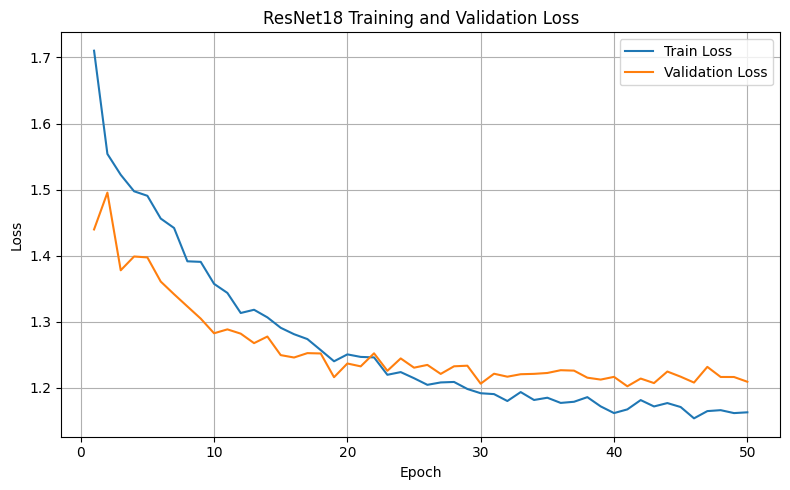

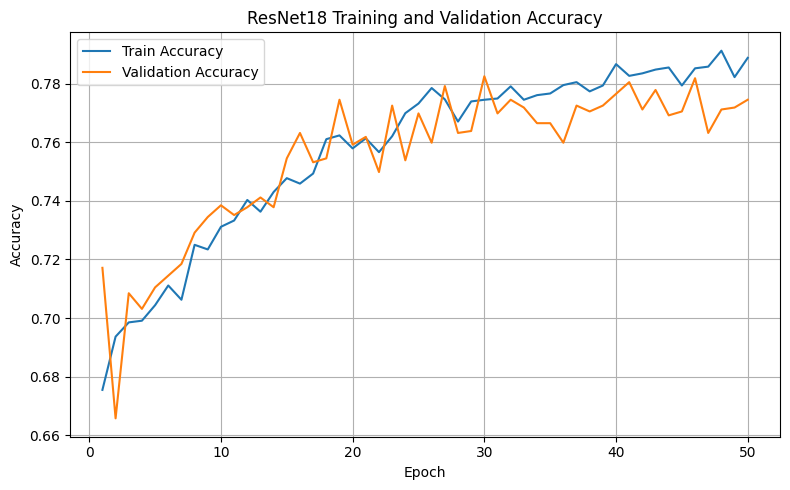

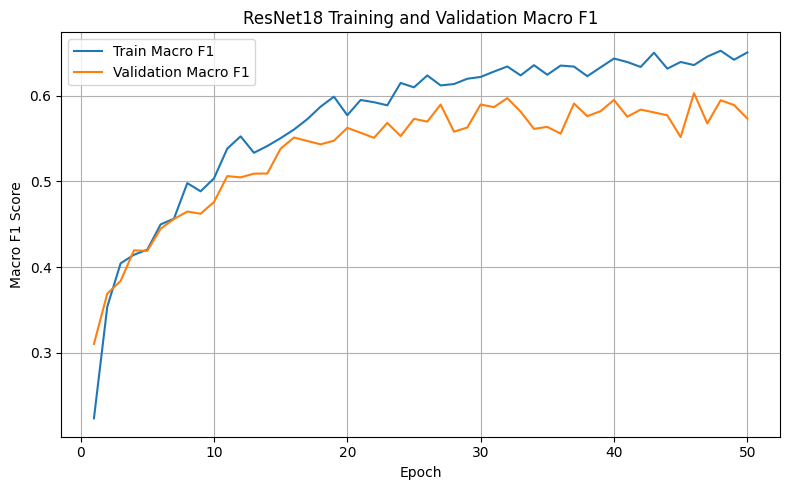

<Figure size 900x800 with 0 Axes>

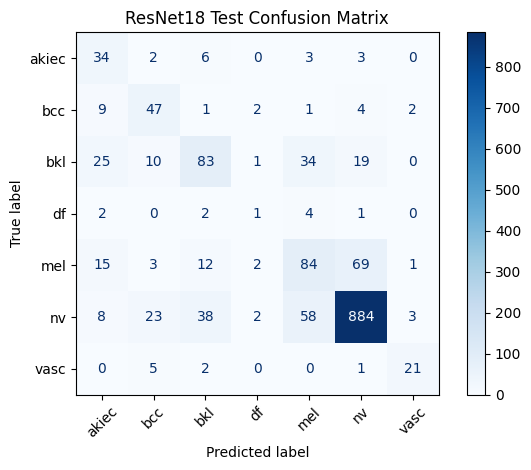

Training curves saved
Confusion matrix saved
Cell 15 complete


In [66]:
history_df = pd.read_csv(HISTORY_FILE)


plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    MODEL_DIR / f"{MODEL_NAME}_loss_curve.png",
    dpi=300
)

plt.show()



plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["validation_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    MODEL_DIR / f"{MODEL_NAME}_accuracy_curve.png",
    dpi=300
)

plt.show()



plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_macro_f1"],
    label="Train Macro F1"
)

plt.plot(
    history_df["epoch"],
    history_df["validation_macro_f1"],
    label="Validation Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1 Score")
plt.title("ResNet18 Training and Validation Macro F1")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    MODEL_DIR / f"{MODEL_NAME}_f1_curve.png",
    dpi=300
)

plt.show()



plt.figure(figsize=(9, 8))

ConfusionMatrixDisplay.from_predictions(
    test_metrics["targets"],
    test_metrics["predictions"],
    labels=list(range(NUM_CLASSES)),
    display_labels=class_names,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("ResNet18 Test Confusion Matrix")
plt.tight_layout()

plt.savefig(
    MODEL_DIR / f"{MODEL_NAME}_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Training curves saved")
print("Confusion matrix saved")
print("Cell 15 complete")

In [ ]:
ZIP_PATH = Path("/kaggle/working") / f"{MODEL_NAME}_HAM10000_results"

zip_file = shutil.make_archive(
    base_name=str(ZIP_PATH),
    format="zip",
    root_dir=str(MODEL_DIR)
)

saved_files = sorted([
    file.name
    for file in MODEL_DIR.iterdir()
    if file.is_file()
])

print("Saved files:")
for file_name in saved_files:
    print("•", file_name)

print("\n" + "=" * 60)
print("ZIP CREATED SUCCESSFULLY")
print("ZIP location:", zip_file)
print("=" * 60)

In [64]:
from IPython.display import FileLink, display

zip_path = "/kaggle/working/resnet18_HAM10000_results.zip"

display(FileLink(
    zip_path,
    result_html_prefix="<b>Download ZIP:</b> "
))

/kaggle/working/resnet18_HAM10000_results.zip